In [2]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv("data.csv")

# Select features
features = ["amount", "applications"]
X = df[features]

# Train Isolation Forest model
model = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
df["ml_flag"] = model.fit_predict(X)
df["ml_flag"] = df["ml_flag"].apply(lambda x: "Fraudulent" if x == -1 else "Legit")

# Rule-based detection
def rule_based(row):
    if row["amount"] > 10000 and row["applications"] > 3:
        return "Fraudulent"
    return "Legit"

df["rule_flag"] = df.apply(rule_based, axis=1)

# Combine ML and rule-based results
df["final_flag"] = df.apply(
    lambda row: "Fraudulent" if (row["ml_flag"] == "Fraudulent" or row["rule_flag"] == "Fraudulent") else "Legit",
    axis=1
)

# Save results
df.to_csv("fraud_detection_results.csv", index=False)
print("✅ Fraud detection complete. Results saved to fraud_detection_results.csv")


✅ Fraud detection complete. Results saved to fraud_detection_results.csv


📊 Scatter plot saved as fraud_detection_scatter.png


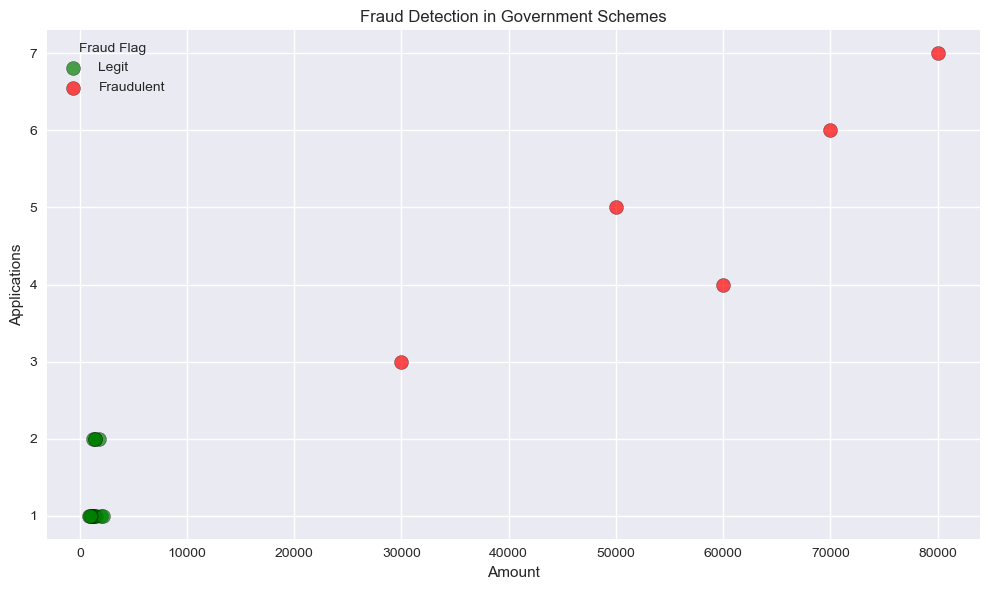

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results
df = pd.read_csv("fraud_detection_results.csv")

# Scatter plot visualization
plt.style.use('seaborn-v0_8')
colors = {"Legit": "green", "Fraudulent": "red"}

plt.figure(figsize=(10, 6))
for label in df["final_flag"].unique():
    subset = df[df["final_flag"] == label]
    plt.scatter(subset["amount"], subset["applications"],
                c=colors[label], label=label, s=100, edgecolors='k', alpha=0.7)

plt.xlabel("Amount")
plt.ylabel("Applications")
plt.title("Fraud Detection in Government Schemes")
plt.legend(title="Fraud Flag")
plt.grid(True)
plt.tight_layout()

plt.savefig("fraud_detection_scatter.png")
print("📊 Scatter plot saved as fraud_detection_scatter.png")


In [7]:
df = pd.read_csv("data.csv")
df.head()

,user_id,amount,applications,location
0,1,1200,1,Delhi
1,2,1500,1,Mumbai
2,3,1800,2,Bangalore
3,4,50000,5,Delhi
4,5,1100,1,Chennai


In [8]:
df.tail()

,user_id,amount,applications,location
15,16,2000,1,Bangalore
16,17,2200,1,Chennai
17,18,30000,3,Delhi
18,19,1000,1,Mumbai
19,20,950,1,Bangalore


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       20 non-null     int64 
 1   amount        20 non-null     int64 
 2   applications  20 non-null     int64 
 3   location      20 non-null     object
dtypes: int64(3), object(1)
memory usage: 772.0+ bytes
